In [1]:
import torch
from gpzoo.kernels import batched_RBF, BatchedBrownianKernel
from torch import distributions
import matplotlib.pyplot as plt
from torch import nn, optim
from tqdm.autonotebook import tqdm
from gpzoo.utilities import add_jitter
from gpzoo.gp import SVGP
from chromgp.models import ChromGP, IntegratedForceGP
from chromgp.utilities import plot_3D, train, train_batched
from chromgp.simulations import make_helix,  generate_simulations, compute_contacts, create_animation

/gladstone/engelhardt/home/lchumpitaz/gitclones/GPzoo/gpzoo/utilities.py:2: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
# Initialize data
N = 10000
# Z = make_helix(num_points=N, radius=1.0, turns=4)
X = torch.linspace(0, 1, N)[:, None]
# simulationsZ, simulations2D = generate_simulations(Z, num_simulations=16, noise_level=15e-2)

In [3]:
epigenetic = torch.sin(20*X)

In [4]:
epigenetic.shape

torch.Size([10000, 1])

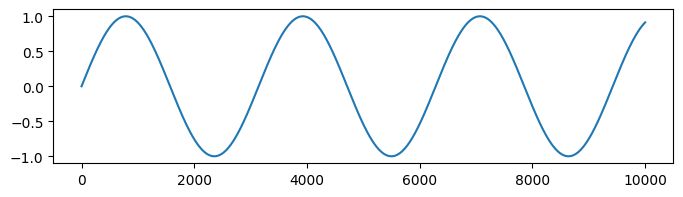

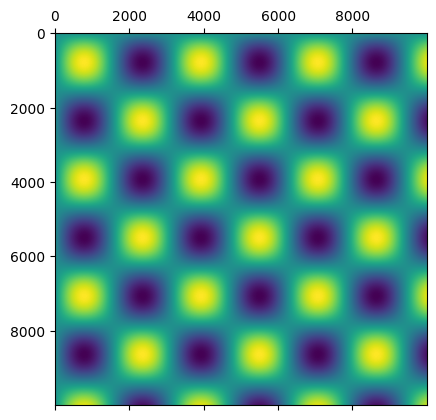

In [5]:
plt.figure(figsize=(8, 2))
plt.plot(epigenetic)
plt.matshow(epigenetic @ epigenetic.T)

In [261]:
eps_random = torch.randn((N, 3))

In [ ]:
kernel1 = BatchedBrownianKernel(sigma=1.0)
kernel2 = batched_RBF(sigma=1.0, lengthscale=1.0)
kernel3 = batched_RBF(sigma=1.0, lengthscale=100.0)

with torch.no_grad():
    E_strength = 0.0
    smooth_strength = 0.1
    X_scaled = 10000*X
    Kxx = kernel1(X_scaled, X_scaled).contiguous()
    Kxx = add_jitter(Kxx, 1e-5)
    Kxx = 10.0*torch.eye(N)#Kxx.diag().diag()
    Kss = kernel2(epigenetic, epigenetic).contiguous()
    Kss = add_jitter(Kss, 3e-4)
    Ksmooth = kernel3(X_scaled, X_scaled).contiguous()
    Ksmooth = add_jitter(Ksmooth, 1e-5)
    L1 = torch.cholesky(Kxx)
    L2 = torch.cholesky(Ksmooth)
    L3 = torch.cholesky(0.5*Kxx + smooth_strength*Ksmooth)

In [ ]:
Z_sample = L1@eps_random
Z_sample = torch.cumsum(Z_sample, dim=0)
E_sample = L2@eps_random
ZE_sample = L3@eps_random
ZE_sample = torch.cumsum(ZE_sample, dim=0)

In [ ]:
Z_sample.shape

In [ ]:
plt.figure(figsize=(14, 3))

# plt.plot(Z_sample);
plt.plot(Z_sample);

In [ ]:
plt.figure(figsize=(14, 3))
plt.plot(ZE_sample);

In [ ]:
plt.figure(figsize=(14, 3))

plt.plot(E_sample);

In [ ]:
plot_3D(ZE_sample, X)

In [ ]:
plot_3D(Z_sample, X)

In [ ]:
ZE_dist = torch.cdist(ZE_sample, ZE_sample)
Z_dist = torch.cdist(Z_sample, Z_sample)

In [ ]:
plt.figure(figsize=(20, 10))
plt.subplot(121)
plt.imshow(torch.log(1/((1+Z_dist)**2)+1e-8), cmap='YlOrRd')
plt.subplot(122)
plt.imshow(torch.log(1/((1+ZE_dist)**2)+1e-9), cmap='YlOrRd')
